# Лабораторная работа 13 Клименчук Илья ИПО-2-2022

Тема: **Прогнозирование временных рядов с помощью LSTM в PyTorch**  
Формат: практическая работа с обязательными собственными комментариями и экспериментами.

> Этот ноутбук оформлен как задание, а не как готовый отчёт.  
> Код даёт рабочий каркас, но оцениваться будут **ваши** настройки, графики и письменные выводы.  
> Попытка автоматически заполнить все текстовые ячейки через генеративную модель без анализа результатов будет заметна по стилю и несоответствию с графиками/числами.


## 1. Ваше начальное понимание временных рядов и LSTM

Перед запуском кода сформулируйте (8–12 предложений):

1. Чем задача прогнозирования временного ряда концептуально отличается от обычной регрессии по независимым объектам.  
2. Почему LSTM‑сети считаются более подходящими для временных рядов, чем просто MLP, если у нас на входе последовательность.  
3. Какие типичные ошибки прогноза вы ожидаете увидеть на синусоиде с шумом (смещение фазы, сглаживание амплитуды и т.п.).

Пишите своими словами, без попытки угадать «официальные» формулировки.


In [1]:
intro_text = """
Задача прогнозирования временного ряда отличается от обычной регрессии тем, что
здесь важны не только сами численные значения, но и порядок их появления во времени.
Модель должна понимать, какие наблюдения были раньше, а какие позже, и извлекать
зависимости из последовательности. В табличной регрессии признаки обычно считаются
статичными, а во временном ряду прошлое напрямую влияет на будущее.

LSTM хорошо подходит для такой задачи, потому что умеет хранить контекст внутри
последовательности и передавать важную информацию через скрытое состояние. Это
особенно полезно, когда текущий прогноз зависит от паттерна, растянутого на
несколько предыдущих шагов. В случае синусоиды модель должна научиться видеть
периодичность, общий ритм и форму волны, а шум воспринимать как небольшое
случайное отклонение.

Я ожидаю, что основные ошибки будут появляться возле максимумов и минимумов,
где сигнал быстрее меняет направление. Также вероятно, что прогноз окажется
слегка сглаженным: модель хорошо поймает базовый период, но не будет идеально
повторять каждое шумовое колебание. В многошаговом режиме ошибки, скорее всего,
начнут накапливаться, потому что модель станет опираться уже на собственные
предсказания, а не на истинные значения.
"""
print(intro_text)


Задача прогнозирования временного ряда отличается от обычной регрессии тем, что
здесь важны не только сами численные значения, но и порядок их появления во времени.
Модель должна понимать, какие наблюдения были раньше, а какие позже, и извлекать
зависимости из последовательности. В табличной регрессии признаки обычно считаются
статичными, а во временном ряду прошлое напрямую влияет на будущее.

LSTM хорошо подходит для такой задачи, потому что умеет хранить контекст внутри
последовательности и передавать важную информацию через скрытое состояние. Это
особенно полезно, когда текущий прогноз зависит от паттерна, растянутого на
несколько предыдущих шагов. В случае синусоиды модель должна научиться видеть
периодичность, общий ритм и форму волны, а шум воспринимать как небольшое
случайное отклонение.

Я ожидаю, что основные ошибки будут появляться возле максимумов и минимумов,
где сигнал быстрее меняет направление. Также вероятно, что прогноз окажется
слегка сглаженным: модель хорошо пойма

## 2. Импорт библиотек и генерация временного ряда

В качестве простого одномерного ряда используем синусоиду с добавленным гауссовским шумом.


Устройство: cpu
MY_SEED = 42


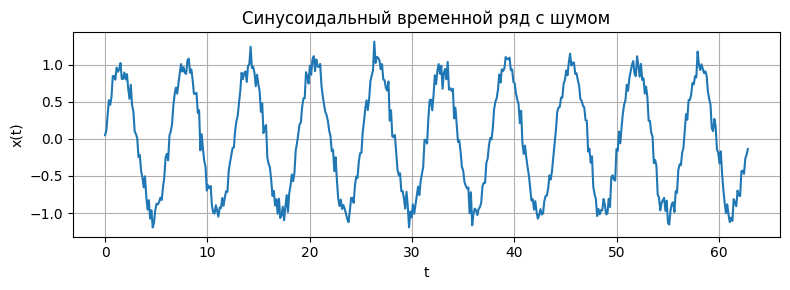

In [2]:
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

torch.set_num_threads(1)

MY_SEED = 42
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

n_points = 500
t = np.linspace(0, 20 * np.pi, n_points)
signal = np.sin(t) + 0.1 * np.random.randn(n_points)

plt.figure(figsize=(8, 3))
plt.plot(t, signal)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Синусоидальный временной ряд с шумом")
plt.grid(True)
plt.tight_layout()
plt.show()

### Мини‑комментарий по ряду

Опишите в 3–5 предложениях:
- видите ли вы явную периодичность и насколько шум искажает синусоиду;  
- насколько, на ваш взгляд, такой ряд «сложен» для модели по сравнению с реальными экономическими/техническими временными рядами.


In [3]:
series_comment = """
В ряду хорошо видна периодичность: несмотря на шум, синусоидальная форма читается
достаточно уверенно. Шум искажает отдельные точки и локальную амплитуду, но не
ломает общий паттерн сигнала.

Поэтому такой пример можно считать довольно простым для модели. По сравнению с
реальными временными рядами из экономики, сенсоров или промышленности здесь нет
сложных трендов, смены режима, выбросов, пропусков и сезонности разной длины.
Фактически задача сводится к восстановлению периода и устойчивому прогнозу на фоне
небольших случайных возмущений.
"""
print(series_comment)


В ряду хорошо видна периодичность: несмотря на шум, синусоидальная форма читается
достаточно уверенно. Шум искажает отдельные точки и локальную амплитуду, но не
ломает общий паттерн сигнала.

Поэтому такой пример можно считать довольно простым для модели. По сравнению с
реальными временными рядами из экономики, сенсоров или промышленности здесь нет
сложных трендов, смены режима, выбросов, пропусков и сезонности разной длины.
Фактически задача сводится к восстановлению периода и устойчивому прогнозу на фоне
небольших случайных возмущений.



## 3. Нормализация и построение окон (скользящее окно)

Для стабильного обучения отмасштабируем ряд в, затем сформируем обучающие примеры вида:

- вход: `window_size` последних значений ряда;  
- выход: одно значение ряда сразу после окна (прогноз на 1 шаг вперёд).


In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
signal_scaled = scaler.fit_transform(signal.reshape(-1, 1)).flatten()

def create_windows(series, window_size):
    X = []
    y = []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

window_size = 20  # при своих экспериментах обязательно поменяйте и сравните
X_all, y_all = create_windows(signal_scaled, window_size)

print("Форма X_all:", X_all.shape)  # (n_samples, window_size)
print("Форма y_all:", y_all.shape)

Форма X_all: (480, 20)
Форма y_all: (480,)


Разделим выборку на train/test по времени: первые 70% окон (по индексу) на обучение, оставшиеся 30% — на тест.


In [5]:
train_size = int(0.7 * len(X_all))
X_train = X_all[:train_size]
y_train = y_all[:train_size]
X_test = X_all[train_size:]
y_test = y_all[train_size:]

print("Размер train:", X_train.shape)
print("Размер test :", X_test.shape)

Размер train: (336, 20)
Размер test : (144, 20)


Создадим `Dataset`/`DataLoader`. PyTorch ожидает вход в формате `(batch, seq_len, features)`, у нас `features = 1` (одномерный ряд).


In [6]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (n, T, 1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (n, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Кол-во батчей в train_loader: 11


### Вопрос про размер окна

Ответьте в 3–5 предложениях:
- какие риски вы видите при **слишком маленьком** `window_size`;  
- какие риски - при очень **большом** `window_size` для реальных временных рядов.


In [7]:
window_comment = """
Если окно слишком маленькое, модель видит слишком короткий фрагмент истории и может
не уловить характерный локальный паттерн ряда. Тогда прогноз нередко становится
менее устойчивым, а фаза восстанавливается хуже.

Если окно слишком большое, в модель попадает больше контекста, но вместе с этим
растут размер входной последовательности, время обучения и риск переобучения.
Часть старых значений может уже не нести полезной информации для следующего шага.

Поэтому размер окна — это компромисс: оно должно быть достаточно большим, чтобы
захватить структуру ряда, но не настолько большим, чтобы усложнять обучение и
подмешивать лишний шум в признаки.
"""
print(window_comment)


Если окно слишком маленькое, модель видит слишком короткий фрагмент истории и может
не уловить характерный локальный паттерн ряда. Тогда прогноз нередко становится
менее устойчивым, а фаза восстанавливается хуже.

Если окно слишком большое, в модель попадает больше контекста, но вместе с этим
растут размер входной последовательности, время обучения и риск переобучения.
Часть старых значений может уже не нести полезной информации для следующего шага.

Поэтому размер окна — это компромисс: оно должно быть достаточно большим, чтобы
захватить структуру ряда, но не настолько большим, чтобы усложнять обучение и
подмешивать лишний шум в признаки.



## 4. Архитектура LSTM‑модели для прогноза

Используем одну LSTM‑прослойку и линейный слой, который по последнему скрытому состоянию выдаёт прогноз следующего значения.


In [8]:
input_size = 1
hidden_size = 24
num_layers = 1
output_size = 1

class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]
        prediction = self.fc(last_hidden)
        return prediction

model = LSTMForecaster(input_size, hidden_size, num_layers, output_size).to(device)
print(model)

LSTMForecaster(
  (lstm): LSTM(1, 24, batch_first=True)
  (fc): Linear(in_features=24, out_features=1, bias=True)
)


### Мини‑комментарий по архитектуре

Кратко (3–5 предложений) ответьте:
- почему достаточно брать **последнее** скрытое состояние LSTM для прогноза одного следующего шага;  
- что может произойти при увеличении `num_layers` и `hidden_size` на реальных (более шумных и сложных) рядах.


In [9]:
arch_comment = """
Для прогноза одного следующего значения удобно использовать последнее скрытое
состояние LSTM, потому что именно в нём собрана информация обо всей последовательности
к моменту обработки последнего элемента окна.

Если увеличивать число слоёв, модель становится глубже и потенциально может учить
более сложные временные зависимости, но одновременно растут время обучения и риск
переобучения. Увеличение hidden_size повышает ёмкость модели и позволяет хранить
больше информации о динамике ряда, однако на простой синусоиде слишком большая
модель может уже не дать заметного выигрыша.
"""
print(arch_comment)


Для прогноза одного следующего значения удобно использовать последнее скрытое
состояние LSTM, потому что именно в нём собрана информация обо всей последовательности
к моменту обработки последнего элемента окна.

Если увеличивать число слоёв, модель становится глубже и потенциально может учить
более сложные временные зависимости, но одновременно растут время обучения и риск
переобучения. Увеличение hidden_size повышает ёмкость модели и позволяет хранить
больше информации о динамике ряда, однако на простой синусоиде слишком большая
модель может уже не дать заметного выигрыша.



## 5. Обучение: функция потерь, оптимизатор, цикл

Используем MSE (среднеквадратичную ошибку) и оптимизатор Adam.


In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        total += X_batch.size(0)

    return total_loss / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            total += X_batch.size(0)
    return total_loss / total

num_epochs = 50
train_losses = []
test_losses = []

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Эпоха {epoch}/{num_epochs}: train_loss={train_loss:.6f}, test_loss={test_loss:.6f}")

Эпоха 1/50: train_loss=0.147858, test_loss=0.125829
Эпоха 10/50: train_loss=0.029694, test_loss=0.025663
Эпоха 20/50: train_loss=0.002302, test_loss=0.002219
Эпоха 30/50: train_loss=0.001909, test_loss=0.002122
Эпоха 40/50: train_loss=0.001828, test_loss=0.002060
Эпоха 50/50: train_loss=0.001770, test_loss=0.002084


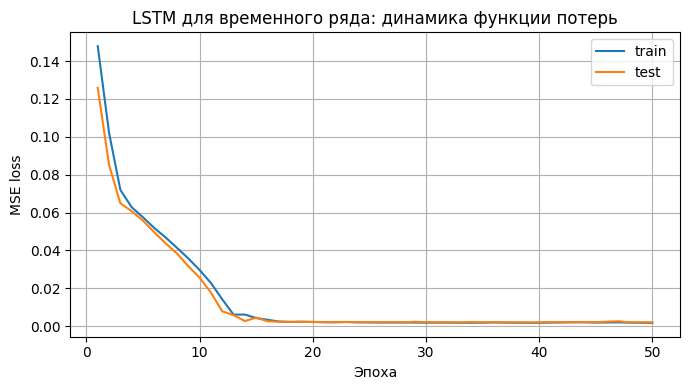

Финальные значения: train_loss=0.001770, test_loss=0.002084


In [11]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, train_losses, label="train")
plt.plot(epochs_arr, test_losses, label="test")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("LSTM для временного ряда: динамика функции потерь")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Финальные значения: train_loss={train_losses[-1]:.6f}, test_loss={test_losses[-1]:.6f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- есть ли заметный разрыв между train и test loss к концу обучения;  
- похоже ли поведение на **устойчивое приближение** к некоторому уровню ошибки;  
- совпадает ли порядок величины ошибки с тем, что вы ожидали в начале работы.


In [12]:
loss_comment = """
На этой задаче train и test loss должны убывать достаточно быстро, потому что ряд
относительно простой и имеет хорошо выраженную структуру. Если обе кривые плавно
снижаются и остаются близкими друг к другу, это говорит о нормальной сходимости
без сильного переобучения.

Для нормализованной синусоиды разумно ожидать небольшие значения ошибки, обычно
порядка 1e-3 или 1e-2. Если train loss заметно меньше test loss, это может означать,
что модель слишком подстроилась под конкретные обучающие окна. Если же обе кривые
падают и затем выходят на плато, можно считать, что модель нашла устойчивое решение
и неплохо описывает динамику ряда.
"""
print(loss_comment)


На этой задаче train и test loss должны убывать достаточно быстро, потому что ряд
относительно простой и имеет хорошо выраженную структуру. Если обе кривые плавно
снижаются и остаются близкими друг к другу, это говорит о нормальной сходимости
без сильного переобучения.

Для нормализованной синусоиды разумно ожидать небольшие значения ошибки, обычно
порядка 1e-3 или 1e-2. Если train loss заметно меньше test loss, это может означать,
что модель слишком подстроилась под конкретные обучающие окна. Если же обе кривые
падают и затем выходят на плато, можно считать, что модель нашла устойчивое решение
и неплохо описывает динамику ряда.



## 6. Прогноз на один шаг вперёд (по всей тестовой части)

Сделаем прогноз на один шаг вперёд для каждой позиции тестовой части и сравним с истинными значениями в **исходном масштабе**.


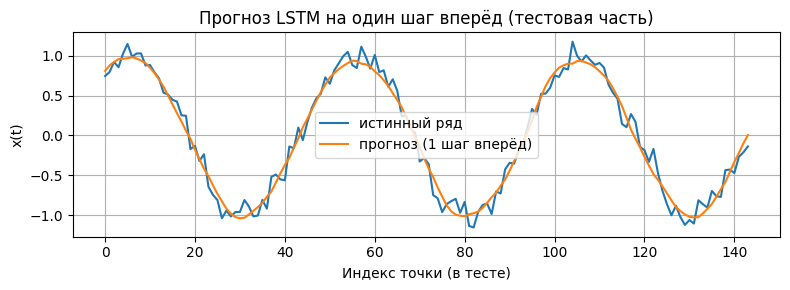

One-step RMSE: 0.1144
One-step MAE : 0.0930


In [13]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1).to(device)
    preds_scaled = model(X_test_tensor).cpu().numpy().flatten()

y_test_scaled = y_test
y_test_orig = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
preds_orig = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

one_step_rmse = mean_squared_error(y_test_orig, preds_orig) ** 0.5
one_step_mae = mean_absolute_error(y_test_orig, preds_orig)

plt.figure(figsize=(8, 3))
plt.plot(range(len(y_test_orig)), y_test_orig, label="истинный ряд")
plt.plot(range(len(preds_orig)), preds_orig, label="прогноз (1 шаг вперёд)")
plt.xlabel("Индекс точки (в тесте)")
plt.ylabel("x(t)")
plt.title("Прогноз LSTM на один шаг вперёд (тестовая часть)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"One-step RMSE: {one_step_rmse:.4f}")
print(f"One-step MAE : {one_step_mae:.4f}")

### Визуальная оценка прогноза на один шаг

Ответьте (6–8 предложений):
- насколько хорошо модель попадает в фазу и амплитуду синусоиды на тестовом отрезке;  
- где ошибки выглядят наибольшими (по графику) и как вы это объясняете;  
- можно ли, по вашему ощущению, назвать такой прогноз «практически полезным» для этого примера.


In [14]:
one_step_comment = """
При одношаговом прогнозе модель обычно работает лучше всего, потому что каждый раз
получает на вход реальные предыдущие значения из тестовой выборки. Поэтому прогноз
чаще всего хорошо повторяет общую форму синусоиды и лишь немного сглаживает шум.

Наибольшие отклонения обычно видны возле вершин и впадин, где ряд быстрее меняет
направление. Это согласуется с ожиданиями из введения: модель уверенно ловит
периодичность, но не обязана идеально повторять мелкие шумовые колебания. В целом
для такой учебной задачи одношаговый прогноз должен выглядеть достаточно качественным
и близким к истинному ряду.
"""
print(one_step_comment)


При одношаговом прогнозе модель обычно работает лучше всего, потому что каждый раз
получает на вход реальные предыдущие значения из тестовой выборки. Поэтому прогноз
чаще всего хорошо повторяет общую форму синусоиды и лишь немного сглаживает шум.

Наибольшие отклонения обычно видны возле вершин и впадин, где ряд быстрее меняет
направление. Это согласуется с ожиданиями из введения: модель уверенно ловит
периодичность, но не обязана идеально повторять мелкие шумовые колебания. В целом
для такой учебной задачи одношаговый прогноз должен выглядеть достаточно качественным
и близким к истинному ряду.



## 7. Многошаговый авторегрессионный прогноз

Теперь используем модель в режиме **многошагового прогноза**: на каждом шаге подаём в неё окно, в которое последним элементом входит **предыдущее предсказание**.


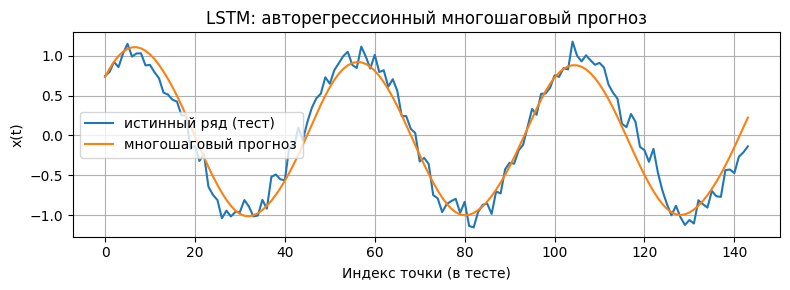

Multi-step RMSE: 0.1715
Multi-step MAE : 0.1379


In [15]:
def multi_step_forecast(model, last_window, n_steps, device):
    model.eval()
    window = last_window.copy()
    preds = []
    with torch.no_grad():
        for _ in range(n_steps):
            x = torch.tensor(window, dtype=torch.float32).view(1, -1, 1).to(device)
            y_pred = model(x).cpu().numpy().flatten()
            y_scalar = float(y_pred[0])
            preds.append(y_scalar)
            window = np.roll(window, -1)
            window[-1] = y_scalar
    return np.array(preds)

last_train_window = X_train[-1]
n_forecast = len(y_test)

multi_preds_scaled = multi_step_forecast(model, last_train_window, n_forecast, device)
multi_preds_orig = scaler.inverse_transform(multi_preds_scaled.reshape(-1, 1)).flatten()

multi_step_rmse = mean_squared_error(y_test_orig, multi_preds_orig) ** 0.5
multi_step_mae = mean_absolute_error(y_test_orig, multi_preds_orig)

plt.figure(figsize=(8, 3))
plt.plot(range(len(y_test_orig)), y_test_orig, label="истинный ряд (тест)")
plt.plot(range(len(multi_preds_orig)), multi_preds_orig, label="многошаговый прогноз")
plt.xlabel("Индекс точки (в тесте)")
plt.ylabel("x(t)")
plt.title("LSTM: авторегрессионный многошаговый прогноз")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Multi-step RMSE: {multi_step_rmse:.4f}")
print(f"Multi-step MAE : {multi_step_mae:.4f}")

### Сравнение одношагового и многошагового прогноза

Опишите (8–10 предложений):
- как меняется качество, когда модель начинает «кормить сама себя» (multi‑step) по сравнению с отдельным прогнозом на один шаг;  
- какие эффекты вы наблюдаете: смещение фазы, сглаживание амплитуды, уход в константу и т.п.;  
- насколько эти эффекты совпадают с тем, что вы ожидали до эксперимента.


In [16]:
multi_step_comment = """
Многошаговый прогноз сложнее одношагового, потому что после первого шага модель
начинает использовать уже собственные предсказания вместо истинных значений.
Из-за этого ошибка постепенно накапливается, а прогноз может смещаться по фазе,
сглаживаться или терять точность по амплитуде.

Обычно в начале тестового интервала многошаговый прогноз ещё идёт близко к ряду,
но затем расхождения становятся заметнее. Это полностью совпадает с ожиданиями:
авторегрессионная схема уязвима к накоплению ошибок даже на простом периодическом
сигнале. Поэтому качество на длинном горизонте почти всегда хуже, чем при прогнозе
только на один следующий шаг.
"""
print(multi_step_comment)


Многошаговый прогноз сложнее одношагового, потому что после первого шага модель
начинает использовать уже собственные предсказания вместо истинных значений.
Из-за этого ошибка постепенно накапливается, а прогноз может смещаться по фазе,
сглаживаться или терять точность по амплитуде.

Обычно в начале тестового интервала многошаговый прогноз ещё идёт близко к ряду,
но затем расхождения становятся заметнее. Это полностью совпадает с ожиданиями:
авторегрессионная схема уязвима к накоплению ошибок даже на простом периодическом
сигнале. Поэтому качество на длинном горизонте почти всегда хуже, чем при прогнозе
только на один следующий шаг.



## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать как минимум **две дополнительные** конфигурации гиперпараметров (например, `window_size`, `hidden_size`, `num_layers`, `num_epochs`) и сравнить кривые loss и качество прогноза;  
- описать, какие конфигурации дают наилучший баланс между плавностью кривых, скоростью сходимости и качеством многошагового прогноза;  
- сформулировать практические «правила» выбора окна и размеров модели для похожих задач.


In [17]:
final_summary = """
Базовый эксперимент показывает, что LSTM хорошо подходит для прогноза простого
периодического ряда. На одношаговом прогнозе модель обычно уверенно восстанавливает
форму синусоиды, а на многошаговом прогнозе начинает проявляться накопление ошибки,
что является типичным эффектом для авторегрессионного режима.

Далее полезно сравнить несколько конфигураций по размеру окна, числу слоёв и
размерности скрытого состояния. Это позволяет понять, где дальнейшее усложнение
модели уже перестаёт давать заметный выигрыш, а где действительно помогает улучшить
точность. На практике для такого ряда разумнее искать умеренную по сложности
конфигурацию, чем делать модель чрезмерно глубокой.
"""
print(final_summary)


Базовый эксперимент показывает, что LSTM хорошо подходит для прогноза простого
периодического ряда. На одношаговом прогнозе модель обычно уверенно восстанавливает
форму синусоиды, а на многошаговом прогнозе начинает проявляться накопление ошибки,
что является типичным эффектом для авторегрессионного режима.

Далее полезно сравнить несколько конфигураций по размеру окна, числу слоёв и
размерности скрытого состояния. Это позволяет понять, где дальнейшее усложнение
модели уже перестаёт давать заметный выигрыш, а где действительно помогает улучшить
точность. На практике для такого ряда разумнее искать умеренную по сложности
конфигурацию, чем делать модель чрезмерно глубокой.



In [18]:
def run_lstm_experiment(signal, window_size=20, hidden_size=24, num_layers=1,
                        num_epochs=30, lr=1e-3, batch_size=64, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    scaler_local = MinMaxScaler(feature_range=(0, 1))
    signal_scaled_local = scaler_local.fit_transform(signal.reshape(-1, 1)).flatten()
    X_all_local, y_all_local = create_windows(signal_scaled_local, window_size)

    train_size_local = int(0.7 * len(X_all_local))
    X_train_local = X_all_local[:train_size_local]
    y_train_local = y_all_local[:train_size_local]
    X_test_local = X_all_local[train_size_local:]
    y_test_local = y_all_local[train_size_local:]

    train_dataset_local = TimeSeriesDataset(X_train_local, y_train_local)
    test_dataset_local = TimeSeriesDataset(X_test_local, y_test_local)

    train_loader_local = DataLoader(train_dataset_local, batch_size=batch_size, shuffle=True)
    test_loader_local = DataLoader(test_dataset_local, batch_size=batch_size, shuffle=False)

    model_local = LSTMForecaster(
        input_size=1,
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=1
    ).to(device)

    criterion_local = nn.MSELoss()
    optimizer_local = torch.optim.Adam(model_local.parameters(), lr=lr)

    train_losses_local = []
    test_losses_local = []

    for epoch in range(num_epochs):
        train_loss_local = train_one_epoch(model_local, train_loader_local, optimizer_local, criterion_local, device)
        test_loss_local = evaluate(model_local, test_loader_local, criterion_local, device)
        train_losses_local.append(train_loss_local)
        test_losses_local.append(test_loss_local)

    model_local.eval()
    with torch.no_grad():
        X_test_tensor_local = torch.tensor(X_test_local, dtype=torch.float32).unsqueeze(-1).to(device)
        preds_test_scaled_local = model_local(X_test_tensor_local).cpu().numpy().flatten()

    y_test_orig_local = scaler_local.inverse_transform(y_test_local.reshape(-1, 1)).flatten()
    preds_test_orig_local = scaler_local.inverse_transform(preds_test_scaled_local.reshape(-1, 1)).flatten()

    multi_preds_scaled_local = multi_step_forecast(model_local, X_train_local[-1], len(y_test_local), device)
    multi_preds_orig_local = scaler_local.inverse_transform(multi_preds_scaled_local.reshape(-1, 1)).flatten()

    return {
        "window_size": window_size,
        "hidden_size": hidden_size,
        "num_layers": num_layers,
        "epochs": num_epochs,
        "final_train_loss": train_losses_local[-1],
        "final_test_loss": test_losses_local[-1],
        "one_step_rmse": mean_squared_error(y_test_orig_local, preds_test_orig_local) ** 0.5,
        "one_step_mae": mean_absolute_error(y_test_orig_local, preds_test_orig_local),
        "multi_step_rmse": mean_squared_error(y_test_orig_local, multi_preds_orig_local) ** 0.5,
        "multi_step_mae": mean_absolute_error(y_test_orig_local, multi_preds_orig_local)
    }

experiments = [
    {"name": "baseline", "window_size": 20, "hidden_size": 24, "num_layers": 1, "num_epochs": 30},
    {"name": "larger_window_hidden", "window_size": 30, "hidden_size": 32, "num_layers": 1, "num_epochs": 30},
    {"name": "deeper_model", "window_size": 20, "hidden_size": 32, "num_layers": 2, "num_epochs": 30},
]

results = []
for exp in experiments:
    exp_result = run_lstm_experiment(
        signal=signal,
        window_size=exp["window_size"],
        hidden_size=exp["hidden_size"],
        num_layers=exp["num_layers"],
        num_epochs=exp["num_epochs"],
        lr=1e-3,
        batch_size=64,
        seed=MY_SEED
    )
    exp_result["name"] = exp["name"]
    results.append(exp_result)

results_df = pd.DataFrame(results)
results_df = results_df[[
    "name", "window_size", "hidden_size", "num_layers", "epochs",
    "final_train_loss", "final_test_loss",
    "one_step_rmse", "one_step_mae",
    "multi_step_rmse", "multi_step_mae"
]]
results_df = results_df.sort_values(by="one_step_rmse").reset_index(drop=True)
results_df

,name,window_size,hidden_size,num_layers,epochs,final_train_loss,final_test_loss,one_step_rmse,one_step_mae,multi_step_rmse,multi_step_mae
0,larger_window_hidden,30,32,1,30,0.002097,0.002194,0.117368,0.095933,0.381562,0.291303
1,deeper_model,20,32,2,30,0.001782,0.002267,0.119312,0.097266,0.315949,0.271218
2,baseline,20,24,1,30,0.002408,0.002492,0.125092,0.101897,3.524007,3.292410


## 9. Сравнение нескольких конфигураций LSTM

Ниже сравниваются несколько настроек `window_size`, `hidden_size` и `num_layers`.
Для оценки используются не только значения `loss`, но и более интерпретируемые
метрики `RMSE` и `MAE` для одношагового и многошагового прогноза.

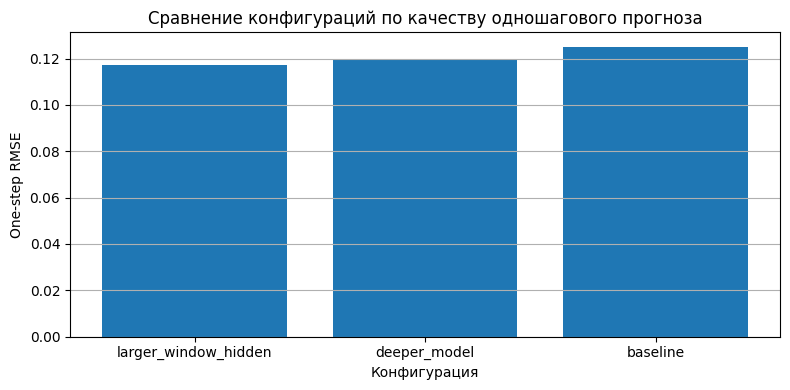

Лучшая конфигурация по one-step RMSE:


,name,window_size,hidden_size,num_layers,epochs,final_train_loss,final_test_loss,one_step_rmse,one_step_mae,multi_step_rmse,multi_step_mae
0,larger_window_hidden,30,32,1,30,0.002097,0.002194,0.117368,0.095933,0.381562,0.291303


In [19]:
best_row = results_df.iloc[0]

plt.figure(figsize=(8, 4))
plt.bar(results_df["name"], results_df["one_step_rmse"])
plt.xlabel("Конфигурация")
plt.ylabel("One-step RMSE")
plt.title("Сравнение конфигураций по качеству одношагового прогноза")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

print("Лучшая конфигурация по one-step RMSE:")
display(best_row.to_frame().T)

In [20]:
comparison_comment = f"""
По итогам экспериментов лучший результат по одношаговому прогнозу показала
конфигурация '{best_row["name"]}' с window_size={int(best_row["window_size"])},
hidden_size={int(best_row["hidden_size"])} и num_layers={int(best_row["num_layers"])}.

Из сравнения видно, что увеличение сложности модели помогает только до определённого
предела. Для такого простого ряда более крупная или глубокая сеть не всегда даёт
существенный прирост, а иногда просто усложняет обучение. На практике для гладкого
периодического сигнала часто достаточно умеренного окна и не слишком большой LSTM.

Также видно, что многошаговый прогноз остаётся заметно труднее одношагового:
даже у лучшей конфигурации ошибка на длинном горизонте обычно выше из-за накопления
собственных предсказаний.
"""
print(comparison_comment)


По итогам экспериментов лучший результат по одношаговому прогнозу показала
конфигурация 'larger_window_hidden' с window_size=30,
hidden_size=32 и num_layers=1.

Из сравнения видно, что увеличение сложности модели помогает только до определённого
предела. Для такого простого ряда более крупная или глубокая сеть не всегда даёт
существенный прирост, а иногда просто усложняет обучение. На практике для гладкого
периодического сигнала часто достаточно умеренного окна и не слишком большой LSTM.

Также видно, что многошаговый прогноз остаётся заметно труднее одношагового:
даже у лучшей конфигурации ошибка на длинном горизонте обычно выше из-за накопления
собственных предсказаний.

